# Algoritmes voor ontwerp van een nok


In [39]:
import numpy as np
import matplotlib.pyplot as plt



<h3>Specificaties</h3>

<a id="specs">Bewegingsspecificatie:</a>

- van 20° tot 90°: heffing van +25 mm.
- van 90° tot 155°: heffing van -15 mm.
- van 155° tot 165°: stilstand op 10 mm.
- van 165° tot 200°: heffing van -10 mm.

De equivalente massa en demping van de volger zijn 30 kg en 0.07.
De volgende statische krachten moeten gerealiseerd worden:

- van 30° tot 90°: een lineair toenemende drukkracht van 0 N tot 550 N.
- van 90° tot 135°: een constante trekkracht van 250 N.
- van 135° tot 180°: een constante trekkracht van 295 N.

De beweging moet uitgevoerd zijn in 1 seconde.


In [40]:
# specifications:

startangle1 = 20 # degrees
endangle1   = 90 # degrees
theta_seg1  = endangle1 - startangle1 # rotation length for first motion segment
startlift1  =  0
endlift1    = 25
motionlaw1  =  5

startangle2 =  90 # degrees
endangle2   = 155 # degrees
theta_seg2  = endangle2 - startangle2 # rotation length for second segment
startlift2  =  25
endlift2    =  10
motionlaw2  =   5

startangle3 = 155 # degrees
endangle3   = 165 # degrees
theta_seg3  = endangle3 - startangle3 # rotation length for third segment
startlift3  =  10
endlift3    =  10
motionlaw3  =   1

startangle4 = 165 # degrees
endangle4   = 200 # degrees
theta_seg4  = endangle4 - startangle4 # rotation length for fourth segment
startlift4  =  10
endlift4    =   0
motionlaw4  =   5

startangleload1 =   30
endangleload1   =   90
startload1      =    0
endload1        =  550

startangleload2 =   90
endangleload2   =  135
startload2      = -250
endload2        = -250

startangleload3 =  135
endangleload3   =  180
startload3      = -295
endload3        = -295


In [41]:
# Simulation variables of cam:

dtheta = 0.01 # resolution of simulation, in degrees

theta_deg      = np.arange(0,360,dtheta) # array of cam angles in degrees
theta          = theta_deg*np.pi/180     # array of cam angles in radians
lift           = np.zeros(len(theta))    # lift follower in mm
vel            = np.zeros(len(theta))    # velocity follower in mm/rad
vel_deg        = np.zeros(len(theta))    # velocity follower in mm/degree
acc            = np.zeros(len(theta))    # acceleration follower in mm/rad^2
acc_deg        = np.zeros(len(theta))    # acceleration follower in mm/degree^2
ext_load       = np.zeros(len(theta))    # external load in N
pressure_angle = np.zeros(len(theta))    # pressure angle in radians

# Cam design parameters, as output of the analysis
base_radius     = [] # base circle radius in mm
follower_radius = [] # follower radius in mm
exc             = [] # excentricity in mm
mass            = [] # equivalent mass in kg
spring_constant = [] # spring constant in N/mm
spring_preload  = [] # spring preload in N
rpm             = [] # rotations per minute of the cam
omega           = [] # angular velocity of the cam in rad/s

# search space of possible R0 values [mm]:
R0_min          =   0
R0_max          = 100 
R0_delta        =   0.1 
R0_vec          = np.arange(R0_min, R0_max, R0_delta) 
# maximum pressure angle corresponding to the evaluated R0s:
alpha_max       = np.zeros_like(R0_vec)

beta_vec        = np.arange(1, 360, 0.1)  # sampling resolution for rotation
rho_min         = np.zeros_like(beta_vec) # minimal follower radius at each beta

# input parameters of several analysis functions:
beta            = [] # cam angle interval of the segment
startangle      = [] # start angle of the segment in degrees
endangle        = [] # end angle of the segment in degrees
startlift       = [] # start lift of the segment in mm
endlift         = [] # end lift of the segment in mm
startangleload  = [] # start angle of the load in degrees
endangleload    = [] # end angle of the load in degrees
startload       = [] # start load in N
endload         = [] # end load in N
motionlaw       = [] # choice of motion law:
    # 1: dwell,
	  # 2: minimal rms acceleration,
	  # 3: harmonic,
	  # 4: cycloid,
	  # 5: 5th degree poly,
	  # 6: 7th degree poly

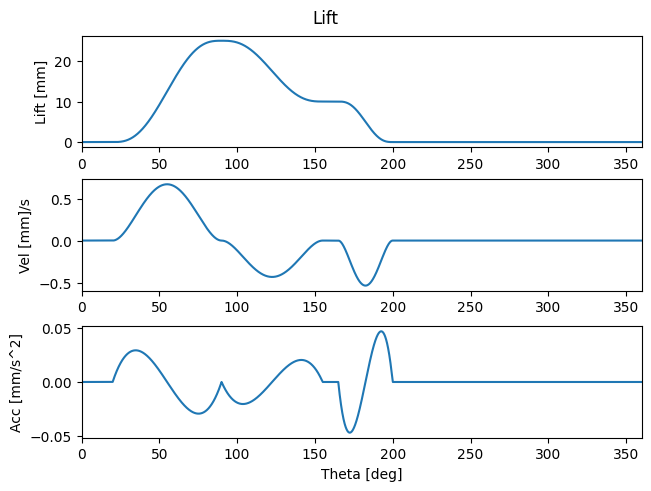

In [42]:
# compute motion functions:

# a motion segment runs in one periodic cycle
# from "startangle" till "endangle",
# and moves from "startlift" till "endlift",
# with a given "motionlaw", and
# with interpolation resolution "dtheta":

def addMotionSegment(startangle,endangle,startlift,endlift,motionlaw,dtheta):
    assert startangle - endangle < 0, 'End angle should be bigger than start angle'
    start_index = int(startangle/dtheta)
    end_index = int(endangle/dtheta)
    beta = endangle - startangle
    L0 = startlift
    L1 = endlift
    x = np.linspace(0, 1, (end_index - start_index))
    if motionlaw == 1:  # dwell
        assert L1 - L0 == 0, 'The given input does not represent a dwell'
        lift[start_index:end_index] = L0 * np.ones_like(x)
        vel_deg[start_index:end_index] = np.zeros_like(x)
        acc_deg[start_index:end_index] = np.zeros_like(x)

    elif motionlaw == 2:  # 3rd order polynomial (minimal rms acceleration)
        L = L1 - L0
        lift[start_index:end_index] = L * (3 * x**2 - 2 * x**3) + L0
        vel_deg[start_index:end_index] = L / beta * (6 * x - 6 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (6 - 12 * x)

    elif motionlaw == 3:  # harmonische
        L = L1 - L0
        lift[start_index:end_index] = L * (1 - np.cos(np.pi * x)) / 2 + L0
        vel_deg[start_index:end_index] = L / beta * np.sin(np.pi * x) * np.pi / 2
        acc_deg[start_index:end_index] = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

    elif motionlaw == 4:  # volle cycloide
        L = L1 - L0
        lift[start_index:end_index] = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
        vel_deg[start_index:end_index] = L / beta * (1 - np.cos(2 * np.pi * x))
        acc_deg[start_index:end_index] = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

    elif motionlaw == 5:  # 5th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
        vel_deg[start_index:end_index] = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

    elif motionlaw == 6:  # 7th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
        vel_deg[start_index:end_index] = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
        acc_deg[start_index:end_index] = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

    vel = vel_deg*180/np.pi
    acc = acc_deg*(180/np.pi)**2

    return lift, vel_deg, acc_deg, vel, acc

def plotMotionLaw(t,lift,vel,acc):
    fig1, ax1 = plt.subplots(nrows=3,ncols=1,constrained_layout=True)
    fig1.suptitle("Lift")
    
    ax1[0].plot(t, lift)
    ax1[0].set_ylabel("Lift [mm]")
    ax1[0].set_xlim([0,360])
    
    ax1[1].plot(t, vel)
    ax1[1].set_ylabel("Vel [mm]/s")
    ax1[1].set_xlim([0,360])
    
    ax1[2].plot(t, acc)
    ax1[2].set_ylabel("Acc [mm/s^2]")
    ax1[2].set_xlabel('Theta [deg]')
    ax1[2].set_xlim([0,360])


# Add all four segments to the motion law:
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle1,endangle1,startlift1,endlift1,motionlaw1,dtheta)
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle2,endangle2,startlift2,endlift2,motionlaw2,dtheta)
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle3,endangle3,startlift3,endlift3,motionlaw3,dtheta)
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle4,endangle4,startlift4,endlift4,motionlaw4,dtheta)


# Plot the motion law
plotMotionLaw(theta_deg,lift,vel_deg,acc_deg)

plt.show()

In [43]:
# utility functions for external load

def addLoadSegment(startangleload,endangleload,startload,endload,dtheta):
    assert startangleload - endangleload < 0, 'End angle should be bigger than start angle'
    start_index = int(startangleload/dtheta)
    end_index = int(endangleload/dtheta)
    theta_segment = theta_deg[start_index:end_index]
    ext_load[start_index:end_index] = (endload - startload)/(endangleload - startangleload)*(theta_segment - startangleload) + startload

    return ext_load

def plotExternalLoad(theta_deg,ext_load):
    plt.figure()
    plt.plot(theta_deg, ext_load)
    plt.xlabel('Theta [deg]')
    plt.ylabel('External load [N]')
    plt.xlim([0,360])
    plt.title('External load')


In [44]:
# utility functions for cam profile design (with eccentricity = 0!)

# relate sampled R0 values to pressure angle \alpha:
def Kloomok_Muffley_R0(beta,startlift,endlift,motionlaw):
    global R0_vec, alpha_max
    L0 = startlift
    L1 = endlift
    beta = beta * np.pi / 180
		# 100 samples in dimensionless "arc length" of motion law:
    x = np.arange(0, 1, 0.01)

    for i in range(len(R0_vec)):
        R0 = R0_vec[i]

        if motionlaw == 1:  # dwell
            assert L1 - L0 == 0, 'The given input does not represent a dwell'
            lift = L0 * np.ones_like(x)
            vel_ang = np.zeros_like(x)
            acc_ang = np.zeros_like(x)

        elif motionlaw == 2:  # minimal rms acceleration
            L = L1 - L0
            lift = L * (3 * x**2 - 2 * x**3) + L0
            vel_ang = L / beta * (6 * x - 6 * x**2)
            acc_ang = L / beta**2 * (6 - 12 * x)

        elif motionlaw == 3:  # harmonische
            L = L1 - L0
            lift = L * (1 - np.cos(np.pi * x)) / 2 + L0
            vel_ang = L / beta * np.sin(np.pi * x) * np.pi / 2
            acc_ang = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

        elif motionlaw == 4:  # volle cycloide
            L = L1 - L0
            lift = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
            vel_ang = L / beta * (1 - np.cos(2 * np.pi * x))
            acc_ang = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

        elif motionlaw == 5:  # 5th degree poly
            L = L1 - L0
            lift = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
            vel_ang = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
            acc_ang = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

        elif motionlaw == 6:  # 7th degree poly
            L = L1 - L0
            lift = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
            vel_ang = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
            acc_ang = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

        alpha = np.arctan2(vel_ang, R0 + lift)
        alpha_max[i] = np.max(np.abs(alpha)) * 180 / np.pi


# relate given R0 value to samples of curvature radii of motion law:
def Kloomok_Muffley_follower_radius(R0,span,startlift,endlift,motionlaw):
    global beta_vec, rho_min
    L0 = startlift
    L1 = endlift

    for i in range(len(beta_vec)):
        beta = beta_vec[i] * np.pi / 180
        theta = np.linspace(0, beta_vec[i], 100) * np.pi / 180
        x = theta / beta

        if motionlaw == 1:  # dwell
            assert L1 - L0 == 0, 'The given input does not represent a dwell'
            lift = L0 * np.ones_like(x)
            vel_ang = np.zeros_like(x)
            acc_ang = np.zeros_like(x)

        elif motionlaw == 2:  # minimal rms acceleration
            L = L1 - L0
            lift = L * (3 * x**2 - 2 * x**3) + L0
            vel_ang = L / beta * (6 * x - 6 * x**2)
            acc_ang = L / beta**2 * (6 - 12 * x)

        elif motionlaw == 3:  # harmonische
            L = L1 - L0
            lift = L * (1 - np.cos(np.pi * x)) / 2 + L0
            vel_ang = L / beta * np.sin(np.pi * x) * np.pi / 2
            acc_ang = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

        elif motionlaw == 4:  # volle cycloide
            L = L1 - L0
            lift = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
            vel_ang = L / beta * (1 - np.cos(2 * np.pi * x))
            acc_ang = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

        elif motionlaw == 5:  # 5th degree poly
            L = L1 - L0
            lift = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
            vel_ang = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
            acc_ang = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

        elif motionlaw == 6:  # 7th degree poly
            L = L1 - L0
            lift = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
            vel_ang = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
            acc_ang = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

        rho = ((R0 + lift)**2 + vel_ang**2)**(3/2) / ((R0 + lift)**2 + 2 * vel_ang**2 - (R0 + lift) * acc_ang)
        rho_min[i] = np.min(np.abs(rho))

    plt.figure()
    plt.plot(beta_vec, rho_min)
    plt.axvline(x=span, color='b')
    plt.text(span, 0.35*R0, 'span of this segment: (%s)'%(span), color='b', ha='right', va='center', rotation='vertical')
    plt.grid()
    plt.xlabel(r'rotation (degrees)')
    plt.ylabel(r'$\rho$ (mm)')
    plt.xlim([0, 360])
    plt.show()


In [45]:
# utility functions for pressure angle

def calculatePressureAngle(vel,exc,base_radius,follower_radius,lift):
    pressure_angle = np.arctan((vel-exc)/(np.sqrt((base_radius+follower_radius)**2-exc**2)+lift))
    return pressure_angle

def plotPressureAngle(theta_deg,pressure_angle):
    plt.figure()
    plt.plot(theta_deg, pressure_angle*180/np.pi)
    plt.xlabel('rotation [deg]')
    plt.ylabel('Pressure angle [deg]')
    plt.xlim([0,360])

In [46]:
# utility functions for curvature radius

def calculateRadiusCurvature(base_radius,follower_radius,exc,theta,lift,vel,acc):
    d = np.sqrt((base_radius + follower_radius)**2 - exc**2) #Nortron, Kinematic and dynamics of Machinery eq. 8.31c
    lambda_ = -theta - np.arctan2(exc, d+lift) + np.pi/2 # Nortron, Kinematic and dynamics of Machinery eq. 8.34, adapted for vertical follower instead of a horizontal one (--> + pi/2)
    dlambda = -1 + exc/((d+lift)**2 + exc**2) * vel # derivative of lambda with repect to theta
    ddlambda = exc/((d+lift)**2 + exc**2)*acc - 2*exc*(d+lift)*vel**2/((d+lift)**2 + exc**2)**2 # 2nd derivative of lambda with repect to theta

    g = np.sqrt((d+lift)**2 + exc**2) 
    dg = vel*(d+lift)/np.sqrt((d+lift)**2 + exc**2) # derivative of g with repect to theta
    ddg = (vel**2  + acc*(d + lift))/np.sqrt((d + lift)**2 + exc**2) - (vel**2*(d + lift)**2)/((d + lift)**2 + exc**2)**(3/2) # 2nd derivative of g with repect to theta

    h = np.sin(lambda_)
    dh = np.cos(lambda_)*dlambda # derivative of h with repect to theta
    ddh = -np.sin(lambda_)*dlambda**2 + np.cos(lambda_)*ddlambda # 2nd derivative of h with repect to theta
    f = np.cos(lambda_)
    df = -np.sin(lambda_)*dlambda #derivative of f with repect to theta
    ddf = -np.cos(lambda_)*dlambda**2 - np.sin(lambda_)*ddlambda # 2nd derivative of f with repect to theta

    dx = df*g + f*dg #derivative of x with repect to theta
    ddx = ddf*g + 2*df*dg + f*ddg # 2nd derivative of x with repect to theta
    dy = dh*g + h*dg # derivative of y with repect to theta
    ddy = ddh*g + 2*dh*dg + h*ddg # 2nd derivative of y with repect to theta

    roc_pitch = -(dx**2 + dy**2)**(3/2) / (dx*ddy - dy*ddx) # general forumula for the radius of curvature
    roc_cam = roc_pitch - follower_radius

    return roc_pitch, roc_cam

def plotRadiusCurvature(theta_deg,roc_pitch,roc_cam):
    inds = np.where(np.abs(np.diff(roc_pitch)/dtheta)<1e3)[0]
    maxi = max(10, max(roc_pitch[inds+1]))
    mini = min(-10, min(roc_pitch[inds+1]))
    plt.figure()
    plt.plot(theta_deg, roc_pitch)
    plt.plot(theta_deg, roc_cam)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Radius of curvature [mm]')
    plt.xlim([0,360])
    plt.ylim([mini,maxi])
    plt.grid()
    plt.title('Radius of curvature')

def plotCamContour(base_radius,follower_radius,exc,theta,lift,pressure_angle,dtheta,):
    d = np.sqrt((base_radius + follower_radius)**2 - exc**2)
    lambda_ = -theta - np.arctan2(exc, d+lift) + np.pi/2
    xpitch = np.cos(lambda_)*np.sqrt((d+lift)**2 + exc**2)
    ypitch = np.sin(lambda_)*np.sqrt((d+lift)**2 + exc**2)

    xcam = xpitch + follower_radius*np.cos(-theta + pressure_angle + 3*np.pi/2)
    ycam = ypitch + follower_radius*np.sin(-theta + pressure_angle + 3*np.pi/2)

    pitch_curve = np.array([xpitch,ypitch])
    cam_curve = np.array([xcam,ycam])

    x_rolfol_center = exc  # x coordinate of the center of the roller of the follower
    y_rolfol_center = d + lift[0]  # y coordinate of the center of the roller of the follower
    x_rolfol = follower_radius * np.cos(theta) + x_rolfol_center  # x coordinate of the contour of the roller
    y_rolfol = follower_radius * np.sin(theta) + y_rolfol_center  # y coordinate of the contour of the roller

    min_distance_center_roller_to_bore = 2 * follower_radius
    height_bore = follower_radius

    width_block_on_follower = base_radius / 2
    height_block_on_follower = base_radius / 2

    x_boreleft = np.array([exc - 5, exc - 1, exc - 1, exc - 5])
    x_boreright = np.array([exc + 5, exc + 1, exc + 1, exc + 5])
    y_bore = np.array([d + max(lift) + min_distance_center_roller_to_bore] * 2 + [d + max(lift) + min_distance_center_roller_to_bore + height_bore] * 2)
    length_follower = y_bore[-1] - ypitch[0] - follower_radius + 0.2

    x_follower = np.array([x_rolfol_center, x_rolfol_center])
    y_follower = np.array([y_rolfol_center + follower_radius, y_rolfol_center + follower_radius + length_follower])

    x_block_on_follower = np.array([-width_block_on_follower, width_block_on_follower, width_block_on_follower, -width_block_on_follower]) + x_follower[0]
    y_block_on_follower = np.array([0, 0, height_block_on_follower, height_block_on_follower]) + y_follower[1]

    ref_line = np.array([[0, 0], [0, base_radius]])  # line, indicating the reference (= cam position = 0 degrees)

    x_pressangle = np.array([x_rolfol_center + follower_radius * np.sin(pressure_angle[0]), x_rolfol_center - follower_radius * np.sin(pressure_angle[0])])
    y_pressangle = np.array([y_rolfol_center - follower_radius * np.cos(pressure_angle[0]), y_rolfol_center + follower_radius * np.cos(pressure_angle[0])])

    plt.figure()
    plt.fill(cam_curve[0, ::int(1 / dtheta)], cam_curve[1, ::int(1 / dtheta)], 'b')
    plt.fill(x_rolfol[::int(1 / dtheta)], y_rolfol[::int(1 / dtheta)], 'g')
    plt.plot(pitch_curve[0, ::int(1 / dtheta)], pitch_curve[1, ::int(1 / dtheta)], '--r')
    plt.plot(0, 0, 'r+')
    plt.plot(x_pressangle, y_pressangle, 'r--')
    plt.plot(ref_line[0, :], ref_line[1, :], 'r--')
    plt.plot(x_boreleft, y_bore, 'r')
    plt.plot(x_boreright, y_bore, 'r')
    plt.plot(x_follower, y_follower, 'r')
    plt.fill(x_block_on_follower, y_block_on_follower, 'g')

    xlimits = [min(pitch_curve[0, :]), max(pitch_curve[0, :])]
    ylimits = [min(pitch_curve[1, :]), d + max(lift) + follower_radius + length_follower + height_block_on_follower]

    plt.xlim(np.array(xlimits) * 1.2)
    plt.ylim(np.array(ylimits) * 1.05)
    plt.gca().set_aspect('equal')
    plt.grid(True)
    plt.title('Cam contour [mm]')

def calculateForce(rpm,lift,spring_constant,spring_preload,pressure_angle,ext_load,mass,acc):
    omega = rpm*2*np.pi/60
    normalforce_spring = (lift*spring_constant+spring_preload)/np.cos(pressure_angle)
    normalforce_load = ext_load/np.cos(pressure_angle)
    normalforce_acc = mass*acc/1000*(omega**2)/np.cos(pressure_angle)
    normalforce_tot = normalforce_spring + normalforce_load + normalforce_acc
    force_x = normalforce_tot * np.sin(pressure_angle)
    force_y = normalforce_tot * np.cos(pressure_angle)

    return normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y

def plotForces(theta_deg,normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y):
    plt.figure()
    plt.plot(theta_deg,normalforce_tot)
    plt.plot(theta_deg,normalforce_acc,'--r')
    plt.plot(theta_deg,normalforce_load,':g')
    plt.plot(theta_deg,normalforce_spring,'-.m')
    plt.xlabel('Theta [deg]')
    plt.ylabel('Normal force [N]')
    plt.xlim([0,360])
    plt.legend(['total','acc','extload','spring'])
    plt.title('Normal force')

    plt.figure()
    plt.plot(theta_deg,force_x)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Force x [N]')
    plt.xlim([0,360])
    plt.title('Force x')

    plt.figure()
    plt.plot(theta_deg,force_y)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Force y [N]')
    plt.xlim([0,360])
    plt.title('Force y')


### Ontwerp van minimale steekcirkel $R_0$

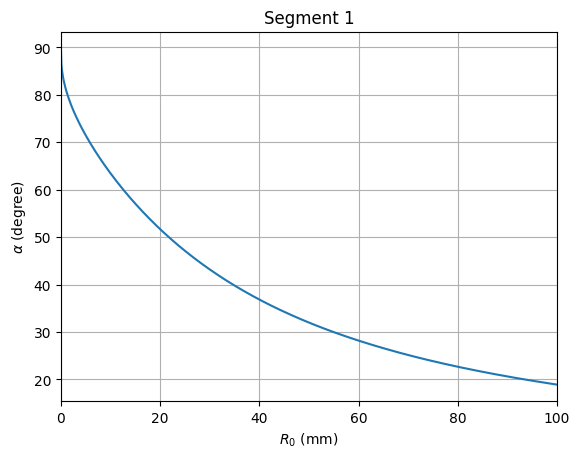

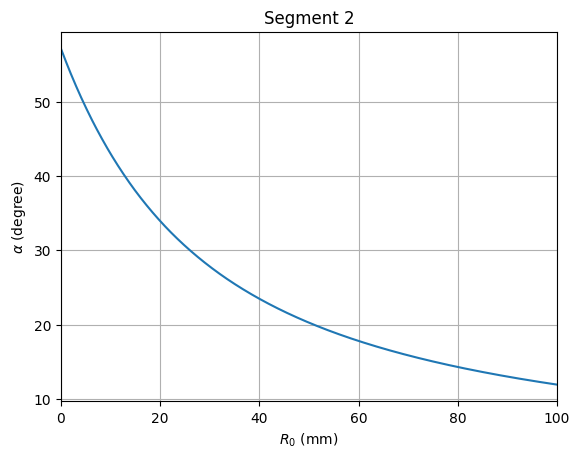

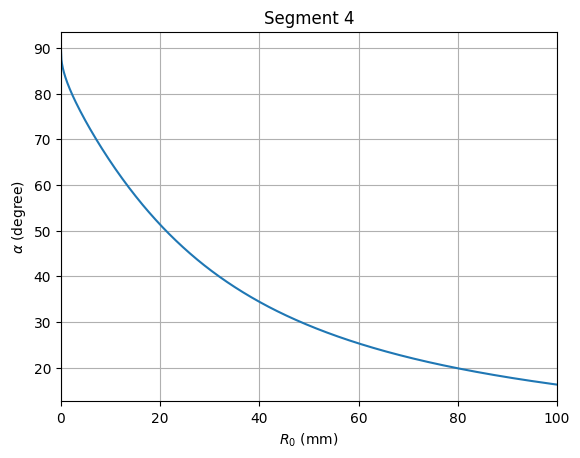

In [47]:
# parameter values for the needed motion segments

# a motion segment runs in one periodic cycle
# from "startangle" till "endangle",
# and moves from "startlift" till "endlift",
# with a given "motionlaw", and
# with interpolation resolution "dtheta":

# The approach was first described by M. Kloomok and R.V. Muffley,
# in Chapter 3 of Mabie, H.H., and Ocvirk, F.W., Mechanisms and Dynamics of Machinery, 1957

def addMotionSegment(startangle,endangle,startlift,endlift,motionlaw,dtheta):
    assert startangle - endangle < 0, 'End angle should be bigger than start angle'
    start_index = int(startangle/dtheta)
    end_index = int(endangle/dtheta)
    beta = endangle - startangle
    L0 = startlift
    L1 = endlift
    x = np.linspace(0, 1, (end_index - start_index))
    if motionlaw == 1:  # dwell
        assert L1 - L0 == 0, 'The given input does not represent a dwell'
        lift[start_index:end_index] = L0 * np.ones_like(x)
        vel_deg[start_index:end_index] = np.zeros_like(x)
        acc_deg[start_index:end_index] = np.zeros_like(x)

    elif motionlaw == 2:  # 3rd order polynomial (minimal rms acceleration)
        L = L1 - L0
        lift[start_index:end_index] = L * (3 * x**2 - 2 * x**3) + L0
        vel_deg[start_index:end_index] = L / beta * (6 * x - 6 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (6 - 12 * x)

    elif motionlaw == 3:  # harmonische
        L = L1 - L0
        lift[start_index:end_index] = L * (1 - np.cos(np.pi * x)) / 2 + L0
        vel_deg[start_index:end_index] = L / beta * np.sin(np.pi * x) * np.pi / 2
        acc_deg[start_index:end_index] = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

    elif motionlaw == 4:  # volle cycloide
        L = L1 - L0
        lift[start_index:end_index] = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
        vel_deg[start_index:end_index] = L / beta * (1 - np.cos(2 * np.pi * x))
        acc_deg[start_index:end_index] = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

    elif motionlaw == 5:  # 5th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
        vel_deg[start_index:end_index] = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

    elif motionlaw == 6:  # 7th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
        vel_deg[start_index:end_index] = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
        acc_deg[start_index:end_index] = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

    vel = vel_deg*180/np.pi
    acc = acc_deg*(180/np.pi)**2

    return lift, vel_deg, acc_deg, vel, acc

def plotMotionLaw(t,lift,vel,acc):
    fig1, ax1 = plt.subplots(nrows=3,ncols=1,constrained_layout=True)
    fig1.suptitle("Lift")
    
    ax1[0].plot(t, lift)
    ax1[0].set_ylabel("Lift [mm]")
    ax1[0].set_xlim([0,360])
    
    ax1[1].plot(t, vel)
    ax1[1].set_ylabel("Vel [mm]/s")
    ax1[1].set_xlim([0,360])
    
    ax1[2].plot(t, acc)
    ax1[2].set_ylabel("Acc [mm/s^2]")
    ax1[2].set_xlabel('Theta [deg]')
    ax1[2].set_xlim([0,360])

# segment 1:
Kloomok_Muffley_R0(theta_seg1,startlift1,endlift1,motionlaw1)

plt.plot(R0_vec, alpha_max)
plt.grid()
plt.title('Segment 1')
plt.xlabel('$R_0$ (mm)')
plt.ylabel(r'$\alpha$ (degree)')
plt.xlim([0, 100])
plt.show()

# segment 2:
Kloomok_Muffley_R0(theta_seg2,startlift2,endlift2,motionlaw2)

plt.figure()
plt.plot(R0_vec, alpha_max)
plt.grid()
plt.title('Segment 2')
plt.xlabel('$R_0$ (mm)')
plt.ylabel(r'$\alpha$ (degree)')
plt.xlim([0, 100])
plt.show()

# segment 3:
Kloomok_Muffley_R0(theta_seg4,startlift4,endlift4,motionlaw4)

plt.figure()
plt.plot(R0_vec, alpha_max)
plt.grid()
plt.title('Segment 4')
plt.xlabel('$R_0$ (mm)')
plt.ylabel(r'$\alpha$ (degree)')
plt.xlim([0, 100])
plt.show()


Uit bovenstaande plots kan een geschikte waarde voor $R_0$ gekozen worden.
<br>
Hier nemen we $R_0 = 60\text{mm}$, omdat de drukhoek hiermee altijd onder 30 graden blijft.


In [48]:
R0 = 60  # pitch radius in mm 



Pas op: als je de nokspecificaties aan het <a href="#specs">begin</a> van deze notebook wijzigt, dan kies je misschien voor een andere $R_0$.

### Ontwerp van straal $R_r$ van de volger

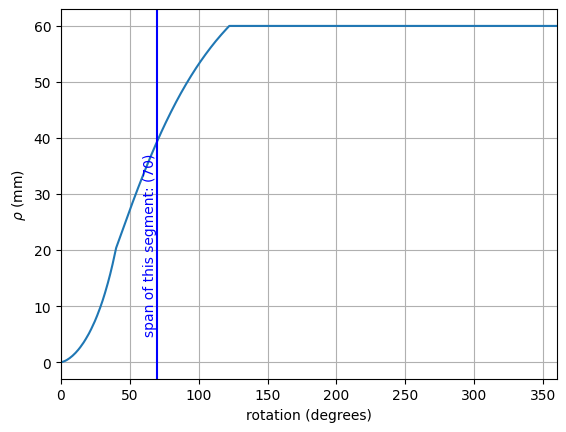

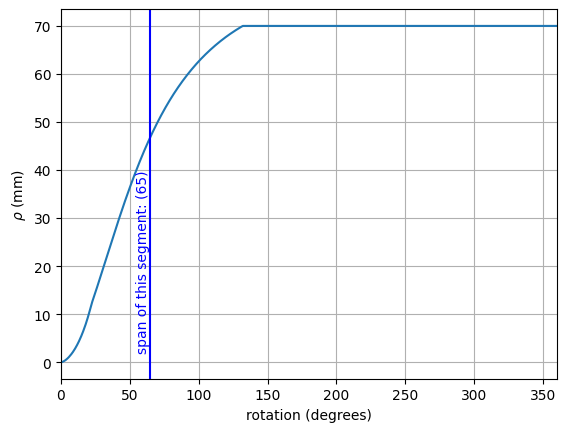

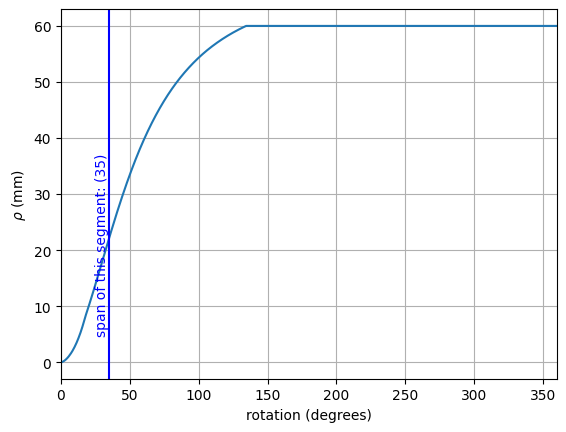

In [49]:
# compute R_r for all segments:

Kloomok_Muffley_follower_radius(R0,theta_seg1,startlift1,endlift1,motionlaw1)
Kloomok_Muffley_follower_radius(R0,theta_seg2,startlift2,endlift2,motionlaw2)
Kloomok_Muffley_follower_radius(R0,theta_seg4,startlift4,endlift4,motionlaw4)

Uit bovenstaande plots kan een geschikte volgrolstraal $R_r$ gekozen worden. De volgrolstraal moet kleiner zijn dan: 40 mm, 50 mm, 25 mm   We nemen $R_r = 15$ mm om goed in de marge te zijn. Dan is de base radius van de nok $R_0 - R_r = 45$ mm.


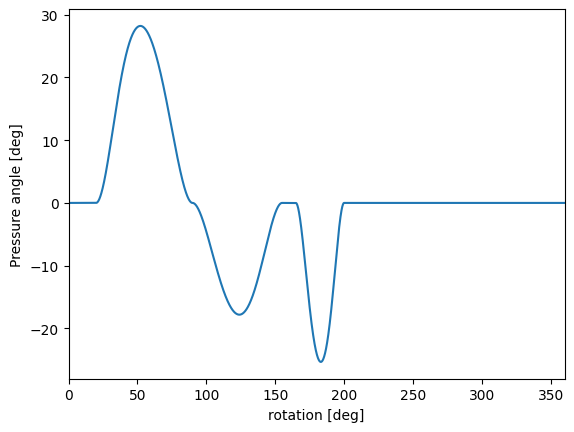

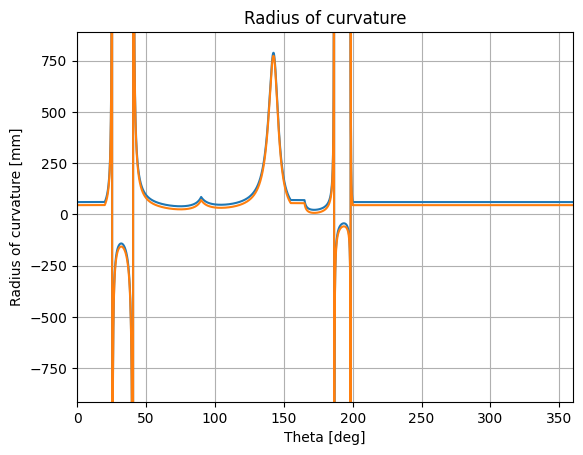

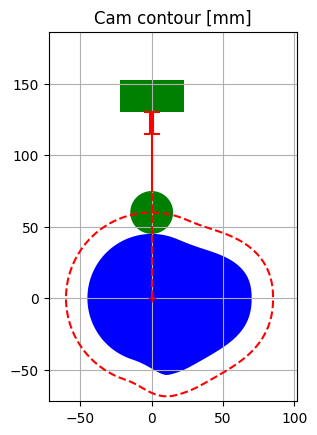

In [50]:
# Kinematics inputs
base_radius     = 45
follower_radius = 15
exc = 0 # excentricity in mm, for now set to 0 for simplicity

# Calculate pressure angle
pressure_angle = calculatePressureAngle(vel,exc,base_radius,follower_radius,lift)
# Plot pressure angle
plotPressureAngle(theta_deg,pressure_angle)

# Calculate radius of curvature
roc_pitch, roc_cam = calculateRadiusCurvature(base_radius,follower_radius,exc,theta,lift,vel,acc)

# Plot the radius of curvature
plotRadiusCurvature(theta_deg,roc_pitch,roc_cam)

# Plot the cam contour
plotCamContour(base_radius,follower_radius,exc,theta,lift,pressure_angle,dtheta)

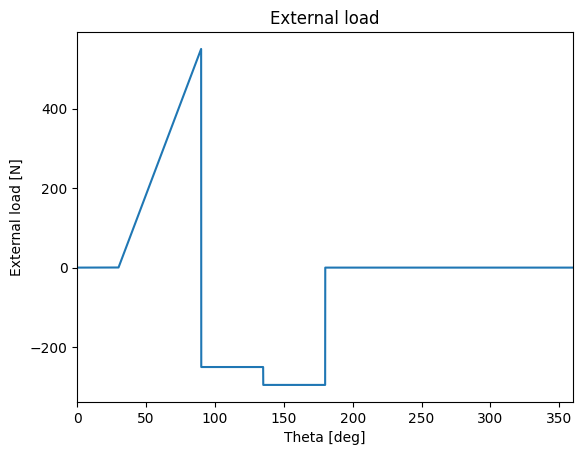

In [51]:
# generate external load

ext_load = addLoadSegment(startangleload1,endangleload1,startload1,endload1,dtheta)
ext_load = addLoadSegment(startangleload2,endangleload2,startload2,endload2,dtheta)
ext_load = addLoadSegment(startangleload3,endangleload3,startload3,endload3,dtheta)

plotExternalLoad(theta_deg,ext_load)



### Ontwerp Veer:

Verticale krachtenevenwicht met zwaartekracht en geleidingswrijving:

- De volger beweegt verticaal.
- De nok geeft een normaalkracht `N` onder drukhoek `alfa`.
- De horizontale geleidingsreactie is `R = N*sin(alfa)`.
- De wrijvingskracht in de geleiding is `F_w = mu*abs(R)` en werkt tegengesteld aan de verticale snelheid van de volger.

Daarom wordt het evenwicht:

`N*(cos(alfa) - mu*abs(sin(alfa))*sign(dy/dt)) = F_veer + F_ext + m*a + m*g`

waarbij `sign(dy/dt)=+1` bij omhoog bewegen en `-1` bij omlaag bewegen.


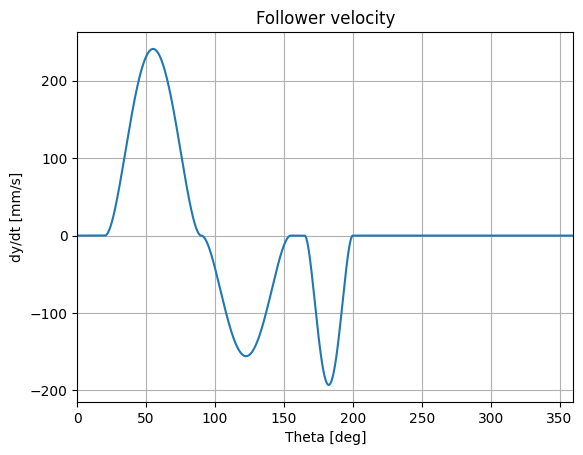

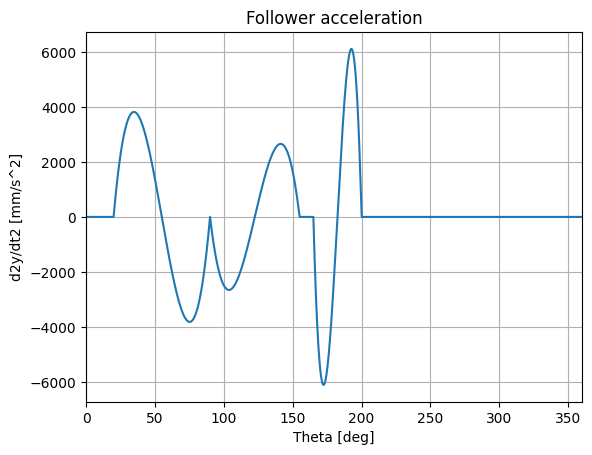

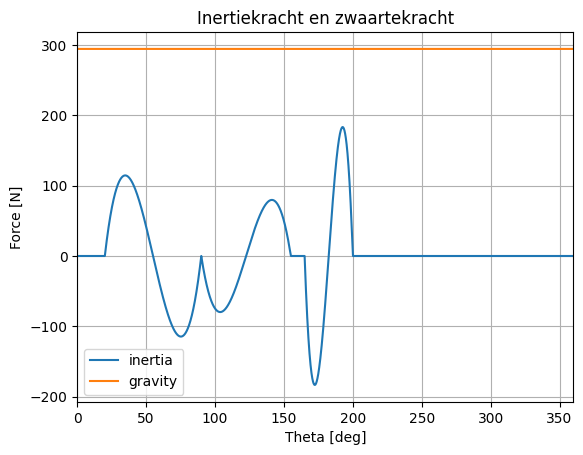

In [52]:
mass = 30
rpm = 60
g_const = 9.81       # [m/s^2]
mu = 0.15            # [-] redelijke schatting staal-op-staal geleiding
omega = rpm*2*np.pi/60

follower_velocity = vel*omega          # dy/dt [mm/s]
follower_acceleration = acc*omega**2   # d2y/dt2 [mm/s^2]

force_acc = mass*follower_acceleration/1000  # [N]
force_gravity = mass*g_const                 # [N]
velocity_sign = np.sign(follower_velocity)

# Door wrijving hangt N impliciet af van zichzelf via R = N*sin(alpha).
# Bij omhoog bewegen werkt wrijving naar beneden: hogere N nodig.
# Bij omlaag bewegen werkt wrijving naar boven: lagere N nodig.
friction_denominator = np.cos(pressure_angle) - mu*np.abs(np.sin(pressure_angle))*velocity_sign

plt.figure()
plt.plot(theta_deg, follower_velocity)
plt.xlabel('Theta [deg]')
plt.ylabel('dy/dt [mm/s]')
plt.xlim([0,360])
plt.grid()
plt.title('Follower velocity')

plt.figure()
plt.plot(theta_deg, follower_acceleration)
plt.xlabel('Theta [deg]')
plt.ylabel('d2y/dt2 [mm/s^2]')
plt.xlim([0,360])
plt.grid()
plt.title('Follower acceleration')

plt.figure()
plt.plot(theta_deg, force_acc, label='inertia')
plt.plot(theta_deg, force_gravity*np.ones_like(theta_deg), label='gravity')
plt.xlabel('Theta [deg]')
plt.ylabel('Force [N]')
plt.xlim([0,360])
plt.grid()
plt.legend()
plt.title('Inertiekracht en zwaartekracht')

def calculateSpringConstant(rpm,lift,vel,acc,pressure_angle,ext_load,mass,spring_preload,mu=0.15,g_const=9.81,contact_margin=0):
    omega = rpm*2*np.pi/60
    follower_velocity = vel*omega
    follower_acceleration = acc*omega**2

    force_acc = mass*follower_acceleration/1000
    force_gravity = mass*g_const
    velocity_sign = np.sign(follower_velocity)
    denominator = np.cos(pressure_angle) - mu*np.abs(np.sin(pressure_angle))*velocity_sign

    # Eis: N >= contact_margin. Omdat N*denominator = F_spring + ext_load + force_acc + force_gravity,
    # moet F_spring minstens dit zijn.
    required_spring_force = contact_margin*denominator - ext_load - force_acc - force_gravity

    mask = lift > 1e-6
    k_values = (required_spring_force[mask] - spring_preload)/lift[mask]

    spring_constant = np.max(k_values)
    spring_constant = max(0,spring_constant)

    critical_index = np.where(mask)[0][np.argmax(k_values)]

    return spring_constant, critical_index, required_spring_force




Best preload = 42.0 N
Best spring constant = 15.372 N/mm
Critical angle = 173.22 deg
Lowest N_rms = 492.35 N
N_min = 0.00 N
N_max = 1270.52 N


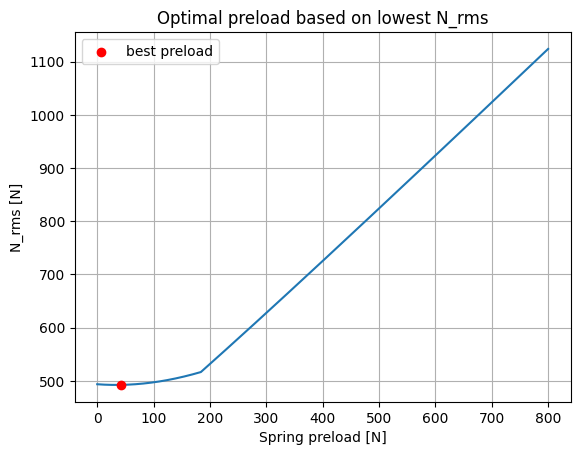

theta = 89.99 deg
total normal force = 1270.52 N


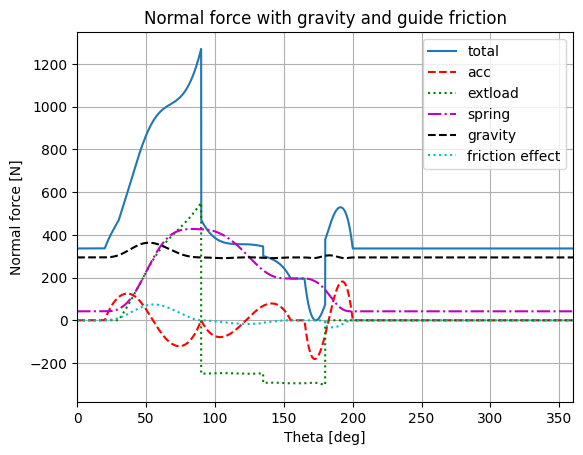

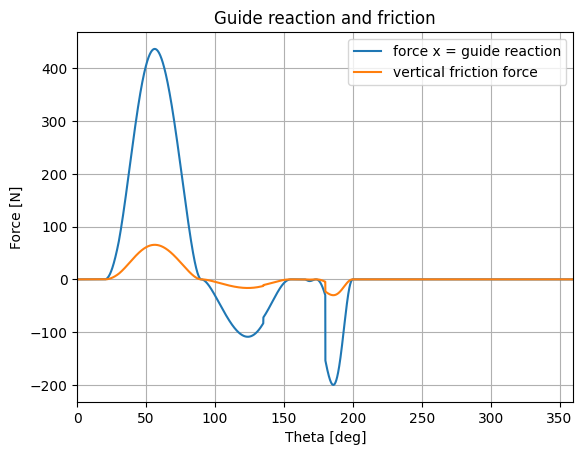

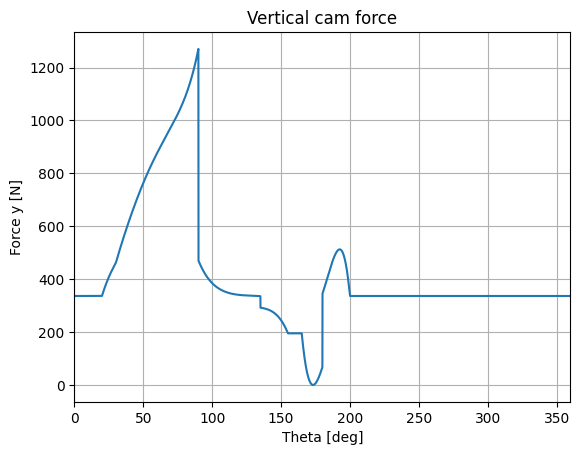

In [53]:
def calculateForce(rpm,lift,vel,spring_constant,spring_preload,pressure_angle,ext_load,mass,acc,mu=0.15,g_const=9.81):
    omega = rpm*2*np.pi/60
    follower_velocity = vel*omega
    follower_acceleration = acc*omega**2

    spring_force = lift*spring_constant + spring_preload
    force_acc = mass*follower_acceleration/1000
    force_gravity = mass*g_const
    velocity_sign = np.sign(follower_velocity)

    denominator = np.cos(pressure_angle) - mu*np.abs(np.sin(pressure_angle))*velocity_sign
    vertical_force_without_friction = spring_force + ext_load + force_acc + force_gravity

    normalforce_tot = vertical_force_without_friction / denominator
    force_x = normalforce_tot * np.sin(pressure_angle)
    force_y = normalforce_tot * np.cos(pressure_angle)

    friction_force = mu*np.abs(force_x)*velocity_sign  # positief = werkt naar beneden op de volger

    normalforce_no_friction = vertical_force_without_friction / np.cos(pressure_angle)
    normalforce_friction = normalforce_tot - normalforce_no_friction
    normalforce_spring = spring_force / denominator
    normalforce_load = ext_load / denominator
    normalforce_acc = force_acc / denominator
    normalforce_gravity = force_gravity / denominator

    return (normalforce_tot, normalforce_acc, normalforce_load, normalforce_spring,
            normalforce_gravity, normalforce_friction, friction_force, force_x, force_y)

def plotForces(theta_deg,normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,normalforce_gravity,normalforce_friction,friction_force,force_x,force_y):
    plt.figure()
    plt.plot(theta_deg,normalforce_tot, label='total')
    plt.plot(theta_deg,normalforce_acc,'--r', label='acc')
    plt.plot(theta_deg,normalforce_load,':g', label='extload')
    plt.plot(theta_deg,normalforce_spring,'-.m', label='spring')
    plt.plot(theta_deg,normalforce_gravity,'--k', label='gravity')
    plt.plot(theta_deg,normalforce_friction,':c', label='friction effect')
    plt.xlabel('Theta [deg]')
    plt.ylabel('Normal force [N]')
    plt.xlim([0,360])
    plt.grid()
    plt.legend()
    plt.title('Normal force with gravity and guide friction')

    plt.figure()
    plt.plot(theta_deg,force_x, label='force x = guide reaction')
    plt.plot(theta_deg,friction_force, label='vertical friction force')
    plt.xlabel('Theta [deg]')
    plt.ylabel('Force [N]')
    plt.xlim([0,360])
    plt.grid()
    plt.legend()
    plt.title('Guide reaction and friction')

    plt.figure()
    plt.plot(theta_deg,force_y)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Force y [N]')
    plt.xlim([0,360])
    plt.grid()
    plt.title('Vertical cam force')

def findBestSpringPreload(rpm,lift,vel,acc,pressure_angle,ext_load,mass,mu=0.15,g_const=9.81,contact_margin=0,preload_min=0,preload_max=800,preload_step=1):
    preload_values = np.arange(preload_min, preload_max + preload_step, preload_step)
    results = []

    for F0 in preload_values:
        spring_constant_i, critical_index_i, required_spring_force_i = calculateSpringConstant(
            rpm,lift,vel,acc,pressure_angle,ext_load,mass,F0,mu,g_const,contact_margin
        )

        normalforce_tot_i, normalforce_acc_i, normalforce_load_i, normalforce_spring_i, normalforce_gravity_i, normalforce_friction_i, friction_force_i, force_x_i, force_y_i = calculateForce(
            rpm,lift,vel,spring_constant_i,F0,pressure_angle,ext_load,mass,acc,mu,g_const
        )

        N_min = np.min(normalforce_tot_i)
        N_max = np.max(normalforce_tot_i)
        N_rms = np.sqrt(np.mean(normalforce_tot_i**2))

        results.append([F0, spring_constant_i, critical_index_i, N_min, N_max, N_rms])

    results = np.array(results)

    # Eerst optimaliseren op laagste N_rms.
    # Als meerdere preloads praktisch dezelfde N_rms geven, kies dan de laagste piek N_max.
    N_rms_values = results[:,5]
    N_max_values = results[:,4]
    # Zelfde N_rms betekent: dezelfde afgeronde waarde op 1 decimaal.
    N_rms_rounded = np.round(N_rms_values, 1)
    min_N_rms_rounded = np.min(N_rms_rounded)
    equal_rms_mask = N_rms_rounded == min_N_rms_rounded
    candidate_indices = np.where(equal_rms_mask)[0]
    best_index = candidate_indices[np.argmin(N_max_values[candidate_indices])]

    best_preload = results[best_index,0]
    best_spring_constant = results[best_index,1]
    best_critical_index = int(results[best_index,2])
    best_N_rms = results[best_index,5]
    best_N_max = results[best_index,4]

    return best_preload, best_spring_constant, best_critical_index, best_N_rms, best_N_max, results

# Zoek automatisch de preload die de laagste N_rms geeft.
preload_min = 0
preload_max = 800
preload_step = 1

Best_preload, veerconstante, critical_index, best_N_rms, best_N_max, preload_results = findBestSpringPreload(
    rpm,lift,vel,acc,pressure_angle,ext_load,mass,mu,g_const,contact_margin,
    preload_min,preload_max,preload_step
)

# Gebruik vanaf hier automatisch de beste preload en bijhorende veerconstante.
spring_preload = Best_preload
spring_constant = veerconstante

(normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,
 normalforce_gravity,normalforce_friction,friction_force,force_x,force_y) = calculateForce(
    rpm,lift,vel,spring_constant,spring_preload,pressure_angle,ext_load,mass,acc,mu,g_const
)

print(f'Best preload = {Best_preload:.1f} N')
print(f'Best spring constant = {spring_constant:.3f} N/mm')
print(f'Critical angle = {theta_deg[critical_index]:.2f} deg')
print(f'Lowest N_rms = {best_N_rms:.2f} N')
print(f'N_min = {np.min(normalforce_tot):.2f} N')
print(f'N_max = {np.max(normalforce_tot):.2f} N')

plt.figure()
plt.plot(preload_results[:,0], preload_results[:,5])
plt.scatter([Best_preload], [best_N_rms], color='red', zorder=3, label='best preload')
plt.xlabel('Spring preload [N]')
plt.ylabel('N_rms [N]')
plt.title('Optimal preload based on lowest N_rms')
plt.grid()
plt.legend()
plt.show()

# Plot forces for the best preload
plotForces(theta_deg,normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,
           normalforce_gravity,normalforce_friction,friction_force,force_x,force_y)

chosen_angle = 89.99
index = np.argmin(np.abs(theta_deg - chosen_angle))
print(f'theta = {theta_deg[index]:.2f} deg')
print(f'total normal force = {normalforce_tot[index]:.2f} N')


### Vliegwiel ontwerpen
1) Vermogen en Koppel van de nok berekenen
2) Fluctuaties in energie de vliegwiel moet oppakken 

In [54]:
omega = rpm*2*np.pi/60

R = base_radius + follower_radius + lift
R_m = R/1000

power_cam = normalforce_tot * np.sin(pressure_angle) * R_m * omega
power_cam_assumptie = mass* follower_acceleration/1000 * follower_velocity/1000 # Als grote deel inertiekracht is.
Torque_cam = power_cam/omega
torque_mean = np.mean(Torque_cam)
torque_fluct = Torque_cam - torque_mean
theta_rad = theta_deg*np.pi/180
energy_fluct = np.cumsum(torque_fluct * np.gradient(theta_rad))
delta_E = np.max(energy_fluct) - np.min(energy_fluct)
K = 0.02 #Fluctuatie-coefficient, fluctuatie van de snelheidsprofiel van: 0.01%
I_flywheel = delta_E / (K * omega**2)


# Geometrie van de vliegwiel
1) R_flywheel = (base_radius + follower_radius + max(lift))/1000 
- Geen extra plaats gebruikt, deze straal is nodig voor de nok dus kan hier ook voor het vliegwiel gebruikt worden.

2) massa_flywheel=I_flywheel/R_flywheel**2 
- Hier R_flywheel dus iets kleiner dan de totale straal van de flywheel want het is de gemmidelide diameter van de rim.
- Te klein dus nemen groter: (t=45m/4m rim/vol)

mean torque = 1.952 Nm
max torque = 32.374 Nm
min torque = -12.672 Nm
max power = 203.415 W
min power = -79.621 W
mean power = 12.262 W
energy fluctuation = 18.023 J
flywheel inertia = 22.826465 kg m^2
Rm= 0.500 m
massa vliegwiel_2= 91.306 kg
dikte rim= 0.074 m
Ri= 0.475 m
RO= 0.525 m


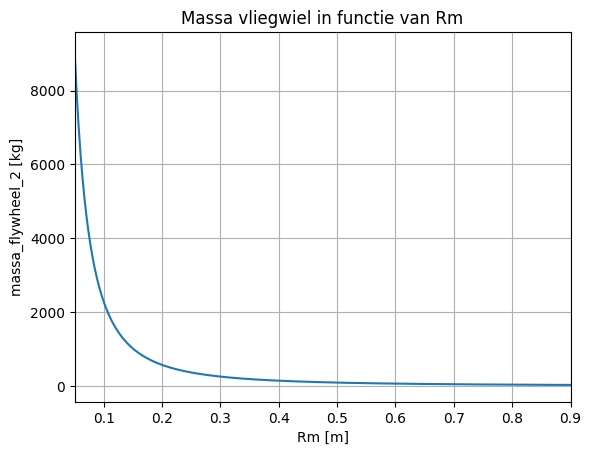

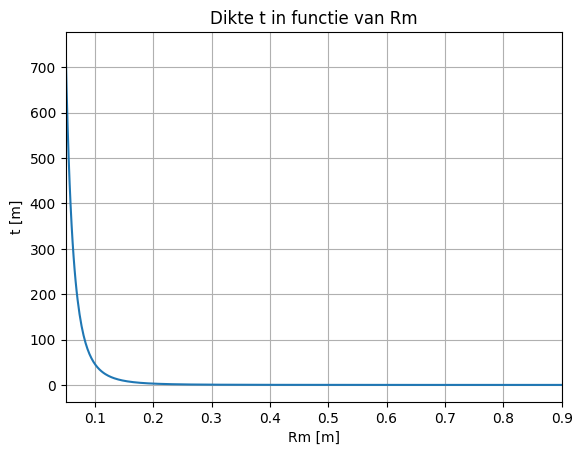

Text(0.5, 1.0, 'Cam torque')

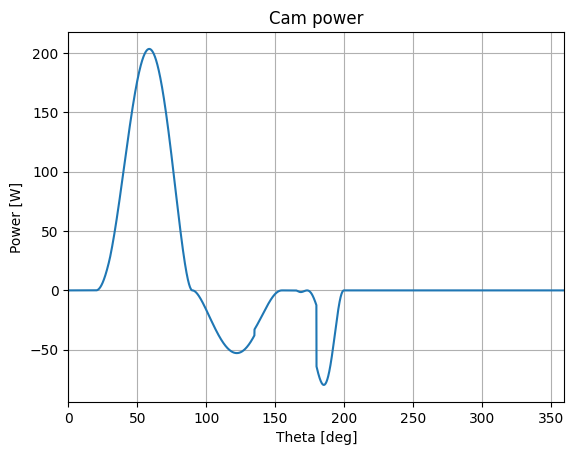

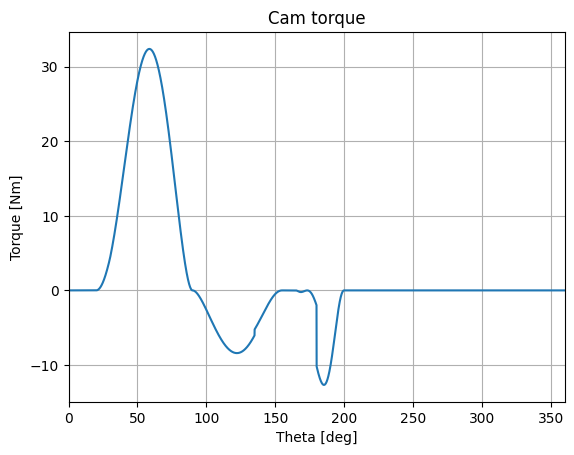

In [55]:



Rm = 0.5 #realistische dikte vliegwiel, itereren tot realistische t ifv Rm zonder dat Rm te groot wordt.
massa_flywheel_2=I_flywheel/Rm**2
b=0.1*Rm 
Ro = Rm + b/2
Ri = Rm - b/2
t_rim=massa_flywheel_2/(np.pi*(Ro**2-Ri**2)*7850)#in m 
t_vol=massa_flywheel_2/(np.pi*Rm**2*7850) 





print(f"mean torque = {torque_mean:.3f} Nm")
print(f"max torque = {np.max(Torque_cam):.3f} Nm")
print(f"min torque = {np.min(Torque_cam):.3f} Nm")
print(f"max power = {np.max(power_cam):.3f} W")
print(f"min power = {np.min(power_cam):.3f} W")
print(f"mean power = {np.mean(power_cam):.3f} W")
print(f"energy fluctuation = {delta_E:.3f} J")
print(f"flywheel inertia = {I_flywheel:.6f} kg m^2")
print(f"Rm= {Rm:.3f} m")
print(f"massa vliegwiel_2= {massa_flywheel_2:.3f} kg")
print(f"dikte rim= {t_rim:.3f} m")
print(f"Ri= {Ri:.3f} m")
print(f"RO= {Ro:.3f} m")
# print(f"dikte volle vliegwiel= {t_vol:.3f} m")

Rm_values = np.linspace(0.05, 0.9, 500)
massa_flywheel_2_values = I_flywheel / Rm_values**2 
rho = 7850          # kg/m^3, staal
b_values = 0.1 * Rm_values
t_values = massa_flywheel_2_values / (rho * 2*np.pi*Rm_values * b_values)

plt.figure()
plt.plot(Rm_values, massa_flywheel_2_values)
plt.xlabel("Rm [m]")
plt.ylabel("massa_flywheel_2 [kg]")
plt.title("Massa vliegwiel in functie van Rm")
plt.grid(True)
plt.xlim(0.05, 0.9)
plt.show()

plt.figure()
plt.plot(Rm_values, t_values)
plt.xlabel("Rm [m]")
plt.ylabel("t [m]")
plt.title("Dikte t in functie van Rm")
plt.grid(True)
plt.xlim(0.05, 0.9)
plt.show()

plt.figure()
plt.plot(theta_deg, power_cam)
plt.xlabel('Theta [deg]')
plt.ylabel('Power [W]')
plt.xlim([0,360])
plt.grid()
plt.title('Cam power')

plt.figure()
plt.plot(theta_deg, Torque_cam)
plt.xlabel('Theta [deg]')
plt.ylabel('Torque [Nm]')
plt.xlim([0,360])
plt.grid()
plt.title('Cam torque')








# Ontwerp van de motor (Met vliegwiel)

motor torque = 1.952 Nm
motor power = 12.262 W
motor torque with safety factor = 2.927 Nm
motor power with safety factor = 18.393 W


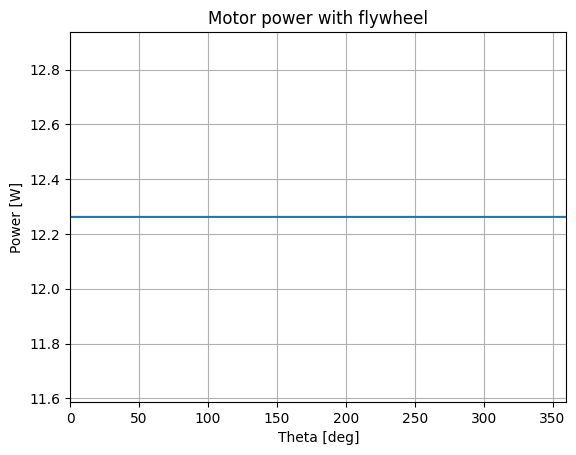

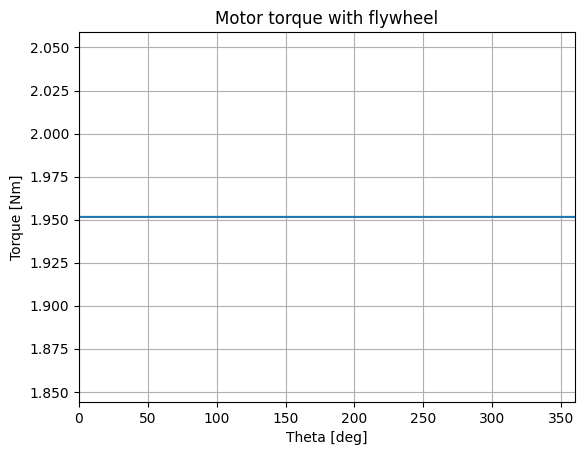

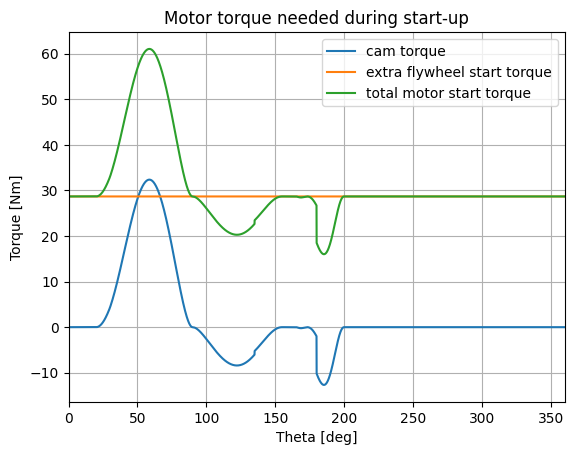

omega = 6.283 rad/s
angular acceleration during start = 1.257 rad/s^2
extra torque to start flywheel = 28.685 Nm
max cam torque = 32.374 Nm
required motor torque for start = 61.059 Nm


In [56]:
# Motor vermogen and motor koppel met vliegwiel
motor_torque = torque_mean * np.ones_like(theta_deg)
motor_power = np.mean(power_cam) * np.ones_like(theta_deg)
print(f"motor torque = {torque_mean:.3f} Nm")
print(f"motor power = {np.mean(power_cam):.3f} W")

# Met veiligheidsfactor van 1.5:
motor_torque_SF = 1.5 * motor_torque
motor_power_SF = 1.5 * motor_power

print(f"motor torque with safety factor = {motor_torque_SF[0]:.3f} Nm")
print(f"motor power with safety factor = {motor_power_SF[0]:.3f} W")

plt.figure()
plt.plot(theta_deg, motor_power)
plt.xlabel("Theta [deg]")
plt.ylabel("Power [W]")
plt.xlim([0,360])
plt.grid()
plt.title("Motor power with flywheel")

plt.figure()
plt.plot(theta_deg, motor_torque)
plt.xlabel("Theta [deg]")
plt.ylabel("Torque [Nm]")
plt.xlim([0,360])
plt.grid()
plt.title("Motor torque with flywheel")


#Kan motor starten op minst gunstige positie:
#Minst gunstige positie= positie waar Torque_cam grootst is.
# Motor torque needed to start from any cam position

t_start = 5  # [s], tijd om van stilstand naar werktoerental te gaan

omega = rpm * 2*np.pi / 60                 # [rad/s]
angular_acc_start = omega / t_start        # [rad/s^2]

# Extra koppel om het vliegwiel op gang te trekken
torque_start_flywheel = I_flywheel * angular_acc_start  # [Nm]

# Koppel dat motor moet leveren bij opstarten:
# 1) koppel om de nok/volger te bewegen
# 2) extra koppel om vliegwiel te versnellen
motor_torque_start = Torque_cam + torque_start_flywheel

# Motor moet kunnen starten op eender welke positie:
motor_torque_required = np.max(motor_torque_start)

plt.figure()
plt.plot(theta_deg, Torque_cam, label="cam torque")
plt.plot(theta_deg, torque_start_flywheel*np.ones_like(theta_deg), label="extra flywheel start torque")
plt.plot(theta_deg, motor_torque_start, label="total motor start torque")
plt.xlabel("Theta [deg]")
plt.ylabel("Torque [Nm]")
plt.xlim([0,360])
plt.grid()
plt.title("Motor torque needed during start-up")
plt.legend()
plt.show()

print(f"omega = {omega:.3f} rad/s")
print(f"angular acceleration during start = {angular_acc_start:.3f} rad/s^2")
print(f"extra torque to start flywheel = {torque_start_flywheel:.3f} Nm")
print(f"max cam torque = {np.max(Torque_cam):.3f} Nm")
print(f"required motor torque for start = {motor_torque_required:.3f} Nm")

In [ ]:
# Drawing: cam follower force diagram

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_aspect('equal')
ax.axis('off')

# Main geometry
cam = plt.Circle((0, 0), 1.0, fill=False, linewidth=2, color='black')
roller = plt.Circle((0.35, 1.35), 0.28, fill=False, linewidth=2, color='black')
follower = plt.Rectangle((0.15, 1.63), 0.4, 1.0, fill=False, linewidth=2, color='black')
guide_left = plt.Rectangle((-0.05, 1.55), 0.08, 1.2, fill=False, linewidth=1.5, color='gray')
guide_right = plt.Rectangle((0.67, 1.55), 0.08, 1.2, fill=False, linewidth=1.5, color='gray')

ax.add_patch(cam)
ax.add_patch(roller)
ax.add_patch(follower)
ax.add_patch(guide_left)
ax.add_patch(guide_right)

# Cam shaft
ax.plot(0, 0, 'ko')
ax.text(-0.12, -0.18, 'O', fontsize=11)

# Spring
spring_x = 0.35
spring_y = np.linspace(2.65, 3.55, 13)
spring_zigzag = spring_x + 0.12*np.array([(-1)**i for i in range(len(spring_y))])
spring_zigzag[0] = spring_x
spring_zigzag[-1] = spring_x
ax.plot(spring_zigzag, spring_y, color='black', linewidth=1.5)
ax.plot([0.05, 0.65], [3.6, 3.6], color='black', linewidth=2)
ax.text(0.55, 3.05, 'veer', fontsize=11)

# Helper for arrows
def arrow(start, end, label, offset=(0, 0), color='tab:blue'):
    ax.annotate('', xy=end, xytext=start, arrowprops=dict(arrowstyle='->', lw=2, color=color))
    ax.text(end[0] + offset[0], end[1] + offset[1], label, color=color, fontsize=11)

# Forces on follower/roller
arrow((0.35, 1.35), (-0.25, 0.75), 'N', offset=(-0.12, -0.05), color='tab:blue')
arrow((0.35, 2.35), (0.35, 1.75), 'F_veer', offset=(0.05, -0.05), color='tab:purple')
arrow((0.52, 2.25), (0.52, 1.65), 'm g', offset=(0.05, -0.05), color='tab:green')
arrow((0.02, 2.15), (-0.45, 2.15), 'R = N sin(alpha)', offset=(-0.55, 0.03), color='tab:orange')
arrow((0.72, 2.05), (0.72, 1.55), 'F_w = mu |R|', offset=(0.05, -0.05), color='tab:red')
arrow((0.2, 2.55), (0.2, 2.95), 'dy/dt', offset=(-0.2, 0.03), color='tab:gray')

# Angle indication
ax.plot([0.35, 0.35], [1.35, 0.8], '--', color='gray', linewidth=1)
ax.text(0.42, 0.95, 'alpha', fontsize=11)

# Labels
ax.text(-0.35, -1.15, 'nok', fontsize=12)
ax.text(0.72, 1.35, 'rolvolger', fontsize=12)
ax.text(0.78, 2.55, 'geleiding', fontsize=12, color='gray')

ax.set_xlim(-1.6, 1.8)
ax.set_ylim(-1.3, 3.9)
ax.set_title('Vrijlichaamsdiagram nok-volger met zwaartekracht en wrijving')
plt.show()
